# Backtest a trading strategy on IG NASDAQ 100 CFD history (`quant-market-data`)

Loads IG's **US Tech 100 Cash (A$1)** daily candles (epic `IX.D.NASDAQ.IFA.IP`)
from the separate `quant-market-data` repo's Postgres database - provider `ig`
/ symbol `NASDAQ100`, i.e. `instrument_id = 1` in its `candles_day` table
(`SELECT * FROM candles_day WHERE instrument_id = 1`) - restricts them to a
chosen date window, runs a strategy through the same backtester
`04_ig_backtest_strategy.ipynb` / `07_nasdaq_backtest_db.ipynb` use
(`trading_toolkit/ig_backtest.py`), and reports the results: a metrics table
(**initial funding -> final funding**), the round-trip trade list, price /
equity / drawdown charts, calendar-year returns and a small strategy sweep.

**Data source** - unlike `07` (Yahoo's raw `^NDX` index level), this is the
IG CFD itself: `quant-market-data` stores IG's bid/ask per bar plus the
canonical `*_price` columns, which for IG are the bid/ask **mid** - so the
prices here match this repo's convention (`(bid + ask) / 2`). The bid/ask
columns are used once, to measure the typical spread and set the trading
cost from it.

**Engine (`ig_backtest.py`)** - a CFD-style fixed-size position: the account
starts with `INITIAL_FUNDING` (default **20,000 AUD**), one index point is
worth `POINT_VALUE` per contract (**1.0 AUD/point** - the "A$1" contract),
and `SIZE` contracts are held, long or short. Signals are BUY / SELL / HOLD, traded the
way `ig_quant_trading` trades them live - an opposite signal closes the
position and opens the reverse one, HOLD keeps it - with fills at the **next bar's open** after a signal (no look-ahead), a flat
`fee_bps` cost per entry and exit. No overnight funding, slippage or margin
calls are modelled - teaching-grade, not an execution simulator.

**Strategy** - the default is `SMAStrategy`: BUY (long) while the fast simple
moving average of the close is above the slow one, SELL (short) while it's below. `BuyHoldStrategy`
is the benchmark. Strategies come from
`ig_quant_trading.strategies` (imported below as `st`) - the sibling
ig-quant-trading repo that trades them live, installed here editable, so
what you backtest is exactly what it runs - every strategy it has (MACD,
Stochastic, ADX, CCI, ...) can be dropped in here. Add your own there by
subclassing `VectorizedStrategy` and implementing `signals(frame)`.

**Prerequisite:** the `trading_toolkit` package installed (`uv sync --extra
dev`) *and* the `quant-market-data` Postgres database running and seeded with
IG history, with `PGHOST`/`PGPORT`/`PGUSER`/`PGPASSWORD`/`PGDATABASE` set in
this repo's `.env` (see `.env.sample`).

## 1. Config, window & strategy

`PROVIDER` / `SYMBOL` pick the instrument out of `quant-market-data`'s
`instruments` table (`ig` / `NASDAQ100` is `instrument_id = 1`, epic
`IX.D.NASDAQ.IFA.IP`); `RESOLUTION` picks the `candles_<resolution>` table.
Set `START` / `END` to bound the backtest (either may be `None`). `FEE_BPS =
None` sets the per-side cost to half the median bid/ask spread (so a round
trip costs one spread) - set a number to override.

In [1]:
import pandas as pd

from ig_quant_trading import strategies as st

from trading_toolkit import ig_backtest as backtest
from trading_toolkit import market_db
from trading_toolkit.constants.ig_ohlc_fields import OHLCField

# quant-market-data instrument to backtest (provider/symbol - see its
# `instruments` table). ig/NASDAQ100 = instrument_id 1, IX.D.NASDAQ.IFA.IP.
PROVIDER = "ig"
SYMBOL = "NASDAQ100"
RESOLUTION = "DAY"

# Backtest window (inclusive). None = use all available history on that side.
START = None
END = None

# Strategy under test.
strategy = st.SMAStrategy(fast_period=10, slow_period=30)

# Account model.
INITIAL_FUNDING = 20_000.0  # starting balance, account currency
POINT_VALUE = 1.0           # A$1 contract: 1 AUD per index point, per contract
SIZE = 1.0                  # contracts held, long or short
CURRENCY = "AUD"
FEE_BPS = None              # None = half the median bid/ask spread, per side

print(f"{PROVIDER}/{SYMBOL}  {RESOLUTION}")
print(f"window  : {START or 'earliest'}  ->  {END or 'latest'}")
print(f"strategy: {strategy.label}")
print(f"account : {INITIAL_FUNDING:,.0f} {CURRENCY}   {SIZE:g} contract(s) @ {POINT_VALUE:g} {CURRENCY}/point")

ig/NASDAQ100  DAY
window  : earliest  ->  latest
strategy: SMA 10/30
account : 20,000 AUD   1 contract(s) @ 1 AUD/point


## 2. Instrument & spread

Looks the instrument up (confirming which `instrument_id` / epic is being
tested) and measures the close bid/ask spread across its `candles_day` rows -
the only place the bid/ask columns are needed.

In [2]:
table = market_db.table_name_for_resolution(RESOLUTION)
conn = market_db.connect()
with conn.cursor() as cur:
    cur.execute(
        "SELECT i.id, i.provider_symbol, i.name "
        "FROM instruments i JOIN providers p ON p.id = i.provider_id "
        "WHERE p.code = %s AND i.symbol = %s",
        (PROVIDER, SYMBOL),
    )
    row = cur.fetchone()
    assert row, f"No instrument {PROVIDER}/{SYMBOL} in quant-market-data"
    instrument_id, epic, name = row
    cur.execute(
        "SELECT close_ask_price - close_bid_price, "
        "(close_ask_price - close_bid_price) / close_price * 10000 "
        f"FROM {table} WHERE instrument_id = %s AND close_bid_price IS NOT NULL",
        (instrument_id,),
    )
    spread = pd.DataFrame(cur.fetchall(), columns=["points", "bps"]).astype(float)

print(f"instrument_id {instrument_id}: {epic}  ({name})")
print(f"close spread  : median {spread['points'].median():.2f} pts "
      f"({spread['bps'].median():.2f} bps), mean {spread['points'].mean():.2f} pts")

if FEE_BPS is None:
    FEE_BPS = round(spread["bps"].median() / 2, 2)
print(f"fee           : {FEE_BPS} bps per side")

instrument_id 1: IX.D.NASDAQ.IFA.IP  (US Tech 100 Cash (A$1))
close spread  : median 2.00 pts (0.96 bps), mean 2.10 pts
fee           : 0.48 bps per side


## 3. Load candles from `quant-market-data`

`market_db.load_candles` yields one flat OHLC dict per candle from the
`*_price` columns (for IG, the bid/ask mid); here they become a
`DatetimeIndex`ed DataFrame clipped to the window.

In [3]:
df = pd.DataFrame(market_db.load_candles(conn, PROVIDER, SYMBOL, RESOLUTION))
conn.close()

assert not df.empty, (
    f"No candles for {PROVIDER}/{SYMBOL} / {RESOLUTION} in quant-market-data - "
    "check its Postgres DB is running and seeded with IG history."
)

df[OHLCField.SNAPSHOT_TIME_UTC] = pd.to_datetime(df[OHLCField.SNAPSHOT_TIME_UTC])
df = df.set_index(OHLCField.SNAPSHOT_TIME_UTC).sort_index()
df = df[[OHLCField.OPEN, OHLCField.HIGH, OHLCField.LOW, OHLCField.CLOSE, OHLCField.VOLUME]]

if START:
    df = df[df.index >= pd.Timestamp(START)]
if END:
    df = df[df.index <= pd.Timestamp(END)]

assert len(df) > 50, (
    f"Only {len(df)} bars in the window - widen START/END."
)
print(f"{len(df)} bars   {df.index[0]:%Y-%m-%d}  ->  {df.index[-1]:%Y-%m-%d}")
df.head()

2095 bars   2020-01-01  ->  2026-09-24


,open,high,low,close,volume
snapshot_time_utc,,,,,
2020-01-01,8747.6,8799.9,8746.8,8796.5,62271
2020-01-02,8796.4,8907.9,8718.5,8759.5,529595
2020-01-03,8759.7,8844.9,8753.0,8794.4,409648
2020-01-05,8745.3,8778.5,8706.7,8745.2,134892
2020-01-06,8745.1,8877.1,8712.6,8863.0,449294


## 4. Run the backtest

`run_backtest` returns a `BacktestResult` (equity curve, trades, stats).
`.summary()` prints the headline metrics; buy & hold over the same window is
shown for comparison.

In [4]:
result = backtest.run_backtest(
    df, strategy,
    initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
    fee_bps=FEE_BPS, currency=CURRENCY,
)
print(result.summary())

strategy           : SMA 10/30
period             : 2020-01-01 -> 2026-09-24  (2095 bars)
initial funding    : 20,000.00 AUD
final funding      : 30,256.11 AUD
profit / loss      : +10,256.11 AUD  (+51.28%)
buy & hold         : +21,802.70 AUD  (+109.01%)
position size      : 1 @ 1 AUD/point   (~0.44x funding at entry)
CAGR               : +6.34%
ann. volatility    : 14.42%
Sharpe (rf=0)      : 0.50
max drawdown       : -17.30%
time in market     : 98.6%  (long 64.7%, short 33.9%)
trades             : 69  (35 long, 34 short)
win rate           : 40.6%
avg / best / worst : +150.40 / +5,188.30 / -1,236.30 AUD


## 5. Trades

One row per round-trip (entry -> exit). `direction` is BUY (long) or SELL
(short); `points` is the price move in the trade's favour,
`pnl` is that move in `CURRENCY` (`points * POINT_VALUE * SIZE`), `open =
True` marks a position still held at the end of the window, marked out at the
last close for accounting.

In [5]:
trades = result.trades.copy()
if not trades.empty:
    trades["return_pct"] = trades["return_pct"].round(2)
trades

,direction,entry_time,exit_time,entry_price,exit_price,points,pnl,return_pct,bars_held,open
0,BUY,2020-02-05,2020-02-28,9425.30,8336.60,-1088.70,-1088.70,-11.55,20,False
1,SELL,2020-02-28,2020-04-08,8336.60,8083.55,253.05,253.05,3.04,34,False
2,BUY,2020-04-08,2020-09-14,8083.55,11298.40,3214.85,3214.85,39.77,135,False
3,SELL,2020-09-14,2020-10-07,11298.40,11390.30,-91.90,-91.90,-0.81,20,False
4,BUY,2020-10-07,2020-10-30,11390.30,11253.10,-137.20,-137.20,-1.20,20,False
...,...,...,...,...,...,...,...,...,...,...
64,BUY,2026-07-09,2026-07-13,29691.20,29417.40,-273.80,-273.80,-0.92,3,False
65,SELL,2026-07-13,2026-08-10,29417.40,29698.10,-280.70,-280.70,-0.95,24,False
66,BUY,2026-08-10,2026-09-01,29698.10,29052.90,-645.20,-645.20,-2.17,19,False
67,SELL,2026-09-01,2026-09-21,29052.90,30120.85,-1067.95,-1067.95,-3.68,17,False


## 6. Charts

Price with the moving averages and buy/sell markers, the strategy equity
curve against buy & hold, and the strategy drawdown.

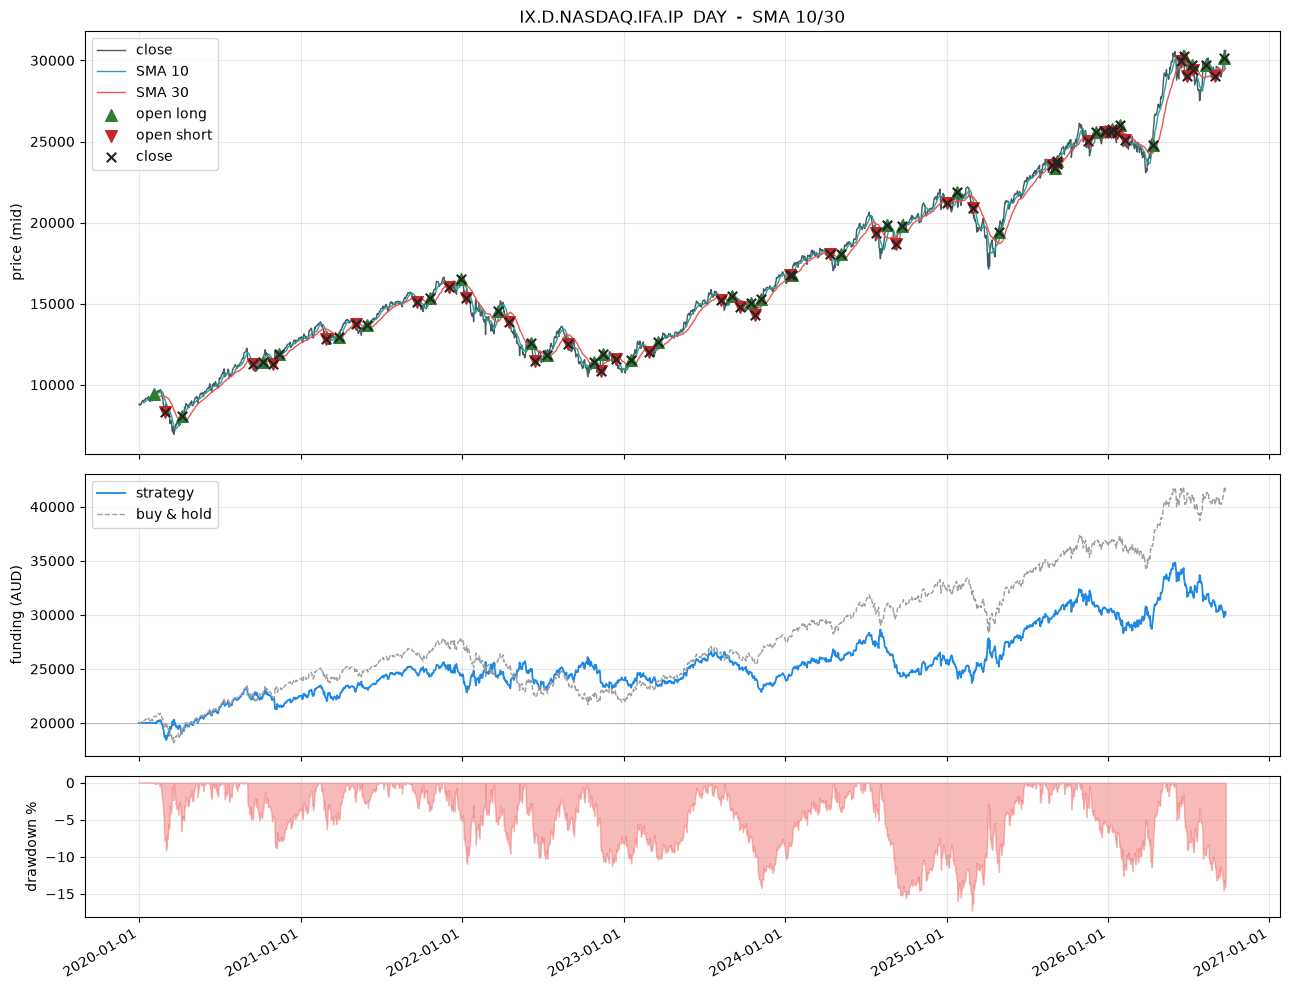

In [6]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

close = df[OHLCField.CLOSE]
eq = result.equity
# buy & hold account value: same funding, same SIZE contracts held throughout
bh = INITIAL_FUNDING + (close - close.iloc[0]) * POINT_VALUE * SIZE
dd = (eq / eq.cummax() - 1) * 100
t = result.trades

fig, (ax_px, ax_eq, ax_dd) = plt.subplots(
    3, 1, sharex=True, figsize=(13, 10),
    gridspec_kw={"height_ratios": [3, 2, 1]},
)

ax_px.plot(close.index, close, color="#455a64", lw=1, label="close")
if hasattr(strategy, "fast_period"):
    ax_px.plot(close.index, close.rolling(strategy.fast_period).mean(), color="#26a69a", lw=1,
               label=f"SMA {strategy.fast_period}")
    ax_px.plot(close.index, close.rolling(strategy.slow_period).mean(), color="#ef5350", lw=1,
               label=f"SMA {strategy.slow_period}")
if not t.empty:
    for side, marker, colour, label in (("BUY", "^", "#2e7d32", "open long"),
                                        ("SELL", "v", "#c62828", "open short")):
        e = t[t["direction"] == side]
        ax_px.scatter(e["entry_time"], e["entry_price"], marker=marker, s=70, color=colour,
                      zorder=5, label=label)
    closed = t[~t["open"]]
    ax_px.scatter(closed["exit_time"], closed["exit_price"], marker="x", s=46, color="#212121",
                  zorder=6, label="close")
ax_px.set_ylabel("price (mid)")
ax_px.set_title(f"{epic}  {RESOLUTION}  -  {strategy.label}")
ax_px.legend(loc="upper left")
ax_px.grid(alpha=0.3)

ax_eq.axhline(INITIAL_FUNDING, color="#bbbbbb", lw=0.8)
ax_eq.plot(eq.index, eq, color="#1e88e5", lw=1.3, label="strategy")
ax_eq.plot(bh.index, bh, color="#9e9e9e", lw=1, ls="--", label="buy & hold")
ax_eq.set_ylabel(f"funding ({CURRENCY})")
ax_eq.legend(loc="upper left")
ax_eq.grid(alpha=0.3)

ax_dd.fill_between(dd.index, dd, 0, color="#ef5350", alpha=0.4)
ax_dd.set_ylabel("drawdown %")
ax_dd.grid(alpha=0.3)

ax_dd.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Calendar-year returns

Strategy vs. buy & hold, per calendar year, as a % of the funding at the
start of that year (the last year is year-to-date).

In [7]:
def yearly_pct(series):
    ends = series.groupby(series.index.year).last()
    starts = ends.shift(1).fillna(series.iloc[0])
    return (ends / starts - 1) * 100

yearly = pd.DataFrame({
    "strategy_%": yearly_pct(eq),
    "buy_hold_%": yearly_pct(bh),
}).round(2)
yearly["diff_pp"] = (yearly["strategy_%"] - yearly["buy_hold_%"]).round(2)
yearly.index.name = "year"
yearly

,strategy_%,buy_hold_%,diff_pp
year,,,
2020,12.42,20.46,-8.04
2021,8.12,14.30,-6.18
2022,-1.24,-19.53,18.29
2023,1.89,26.45,-24.56
2024,4.15,14.97,-10.82
2025,18.60,13.06,5.54
2026,0.13,14.77,-14.64


## 8. Compare a few strategies

Same window, same costs - a quick sweep so the numbers above have something
to sit against. Edit the list to taste.

In [8]:
candidates = [
    st.BuyHoldStrategy(),
    st.SMAStrategy(5, 20),
    st.SMAStrategy(10, 30),
    st.SMAStrategy(20, 50),
    st.SMAStrategy(50, 100),
]

rows = []
for strat in candidates:
    try:
        s = backtest.run_backtest(
            df, strat,
            initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
            fee_bps=FEE_BPS, currency=CURRENCY,
        ).stats
    except ValueError as exc:  # e.g. slow window longer than the data
        print(f"skip {strat.label}: {exc}")
        continue
    rows.append({
        "strategy": strat.label,
        f"final_funding_{CURRENCY}": round(s["final_funding"], 2),
        f"profit_{CURRENCY}": round(s["profit"], 2),
        "return_%": round(s["total_return_pct"], 2),
        "max_dd_%": round(s["max_drawdown_pct"], 2),
        "sharpe": round(s["sharpe"], 2),
        "exposure_%": round(s["exposure_pct"], 1),
        "trades": s["n_trades"],
    })

pd.DataFrame(rows).set_index("strategy")

,final_funding_AUD,profit_AUD,return_%,max_dd_%,sharpe,exposure_%,trades
strategy,,,,,,,
buy & hold,41802.38,21802.38,109.01,-22.10,0.89,100.0,1
SMA 5/20,16385.11,-3614.89,-18.07,-39.17,-0.08,99.0,127
SMA 10/30,30256.11,10256.11,51.28,-17.30,0.50,98.6,69
SMA 20/50,22349.34,2349.34,11.75,-40.82,0.18,97.6,39
SMA 50/100,22650.67,2650.67,13.25,-25.66,0.20,95.2,17
